In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.interpolate
import importlib

In [2]:
import modules.loaddata
spectral_q, spectral_vals = modules.loaddata.load_spectral("./data/sf_nu_responses/")
ab_initio_q, ab_initio_vals = modules.loaddata.load_ab_initio("./data/ab_initio_nu_responses/")

# Data prep

In [64]:
USE_RESIDUALS = 1

In [ ]:
# import modules.interpolation_preprocess
# import importlib
# importlib.reload(modules.interpolation_preprocess)
# preprocess_transform_params = modules.interpolation_preprocess.get_transform_params(spectral_q, spectral_vals)
# spectral_vals_transformed = modules.interpolation_preprocess.transform_data(spectral_q, spectral_vals, preprocess_transform_params)

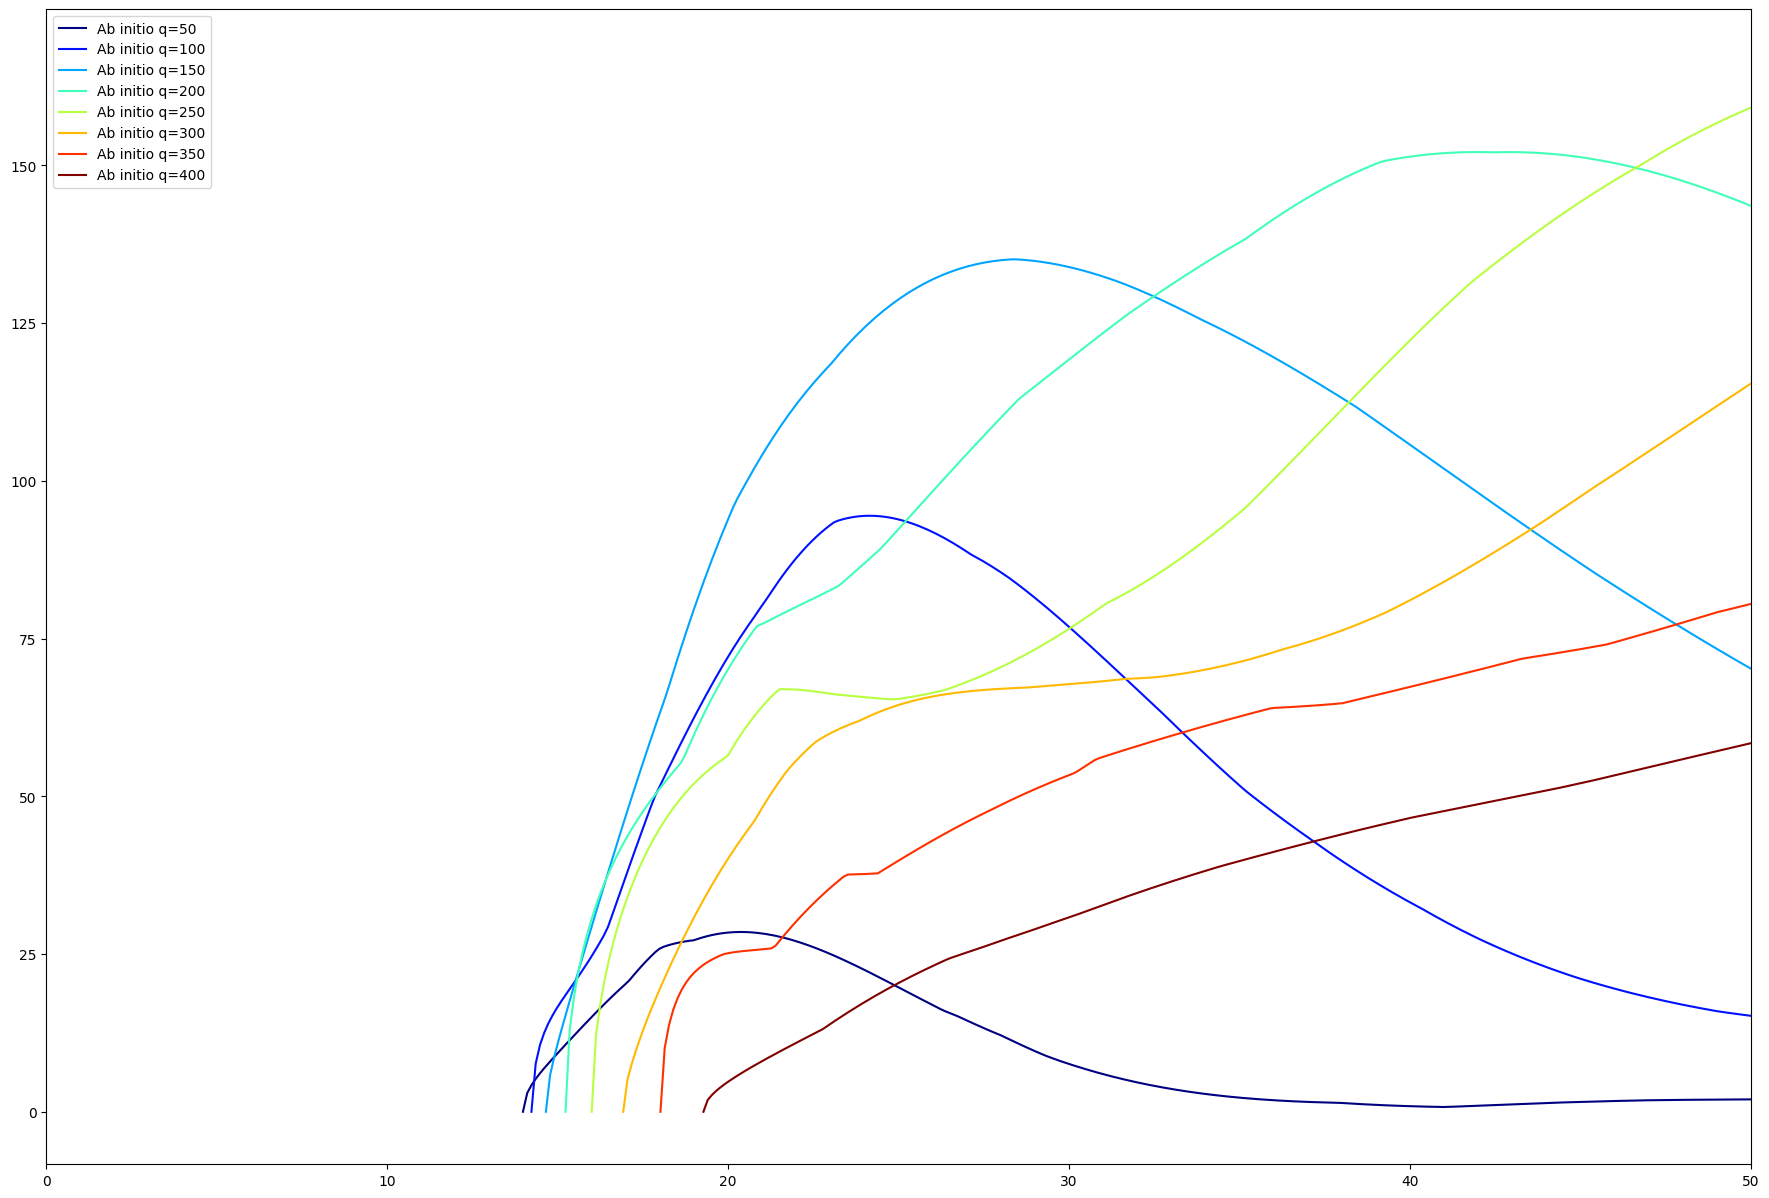

In [77]:
plt.figure(figsize=(22, 15))
import modules.utils

colors = modules.utils.generate_colourscale(len(ab_initio_q))
for (i, vals) in enumerate(ab_initio_vals):
    plt.plot(vals[0,0], vals[0,1], color=colors[i], label=f"Ab initio q={ab_initio_q[i]}")
plt.xlim(0, 50)
plt.legend()

In [3]:
importlib.reload(modules.loaddata)
spectral_functions = modules.loaddata.build_spectral_interpolator(spectral_q, spectral_vals)

# === Test for q = 400MeV
# wcoord = np.arange(0, 500, 1)
# vals = spectral_functions[0]((400, np.array(wcoord)))
# curve_idx = 0
# plt.plot(wcoord, vals, label="Interpolated")
# plt.plot(spectral_vals[-2,curve_idx,0], spectral_vals[-2,curve_idx,1], label="Source")
# plt.plot(ab_initio_vals[-1,curve_idx,0], ab_initio_vals[-1,curve_idx,1], label="Ab initio")
# plt.legend()

In [65]:
# Compute residuals
residual = ab_initio_vals.copy()
for (q_idx, q) in enumerate(ab_initio_q):
    for (curve_idx, curve) in enumerate(ab_initio_vals[q_idx]):
        residual[q_idx, curve_idx, 1] = curve[1] - USE_RESIDUALS*spectral_functions[curve_idx]((q, curve[0]))

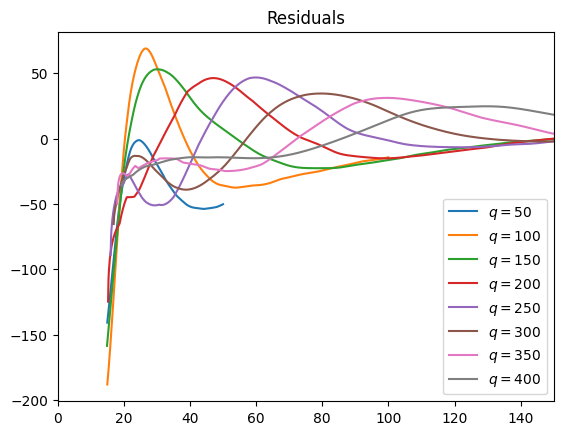

In [66]:
# Plot residuals
# plt.figure(figsize=(15, 10))
for i in range(8):
    plt.plot(residual[i,curve_idx,0], residual[i,curve_idx,1], label=f"$q={ab_initio_q[i]}$")
plt.xlim(0, 150)
plt.title("Residuals")
plt.legend()
pass

# Torch Setup

In [37]:
from torch import nn
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
if device == "cuda":
    print("CUDA available")
else:
    print("⚠️ CUDA not available ⚠️")

CUDA available


In [55]:
# This class loads the data and splits it into training and test. It can be configured multiple times, 
class DataManager():
    def __init__(self, spectral_q, spectral_vals, ab_initio_q, ab_initio_vals, residual):
        self.spectral_q = spectral_q
        self.spectral_vals = spectral_vals
        self.ab_initio_q = ab_initio_q
        self.ab_initio_vals = ab_initio_vals
        self.residual = residual
    
    def configure_data(self, q_to_test=[]):
        X_train = []
        Y_train = []
        
        X_test = []
        Y_test = []


        for q_idx, q in enumerate(self.ab_initio_q):
            # TODO: Check that they actually share w values
            w_vals = self.residual[q_idx, 0, 0]
            
            y0 = self.residual[q_idx, 0, 1]
            y1 = self.residual[q_idx, 1, 1]
            y2 = self.residual[q_idx, 2, 1]
            
            for i, w in enumerate(w_vals):
                if not q > w: # skip nonphysical poins
                    continue
                # Skip points where any of the curves resulted in NaN. Spectral functions only cover the valid region q<w, while ab initio extends outside that
                if not (np.isnan(y0[i]) or np.isnan(y1[i]) or np.isnan(y2[i])):
                    x = [w, q]
                    y = [y0[i], y1[i], y2[i]]
                    if q in q_to_test:
                        X_test.append(x)
                        Y_test.append(y)
                    else:
                        X_train.append(x)
                        Y_train.append(y)

        X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
        Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
        
        X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        Y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)

        # Normalized data
        self.X_mean = X_train.mean(dim=0, keepdim=True)
        self.X_std = X_train.std(dim=0, keepdim=True)
        self.Y_mean = Y_train.mean(dim=0, keepdim=True)
        self.Y_std = Y_train.std(dim=0, keepdim=True)

        X_train = (X_train - self.X_mean) / self.X_std
        Y_train = (Y_train - self.Y_mean) / self.Y_std
        
        X_test = (X_test - self.X_mean) / self.X_std
        Y_test = (Y_test - self.Y_mean) / self.Y_std


        from torch.utils.data import TensorDataset, DataLoader

        train_dataset = TensorDataset(X_train, Y_train)
        train_dataloader = DataLoader(train_dataset, batch_size=20000, shuffle=True)
        
        test_dataset = TensorDataset(X_test, Y_test)
        test_dataloader = DataLoader(test_dataset, batch_size=20000, shuffle=False)

        # print(f"X_train shape: {X_train.shape}")
        # print(f"Y_train shape: {Y_train.shape}")
        self.train_dataloader = train_dataloader
        self.test_dataloader = test_dataloader

In [56]:
class NNParams:
    def __init__(self, layers = [1024, 1024, 128], learning_rate = 1e-3):
        self.layers = layers
        self.learning_rate = learning_rate

In [57]:
def custom_loss(pred, target):
    return torch.mean(torch.abs(pred - target)*torch.abs(target))

In [ ]:
# Create model
class ResidualNN(nn.Module):
    def __init__(self, dataManager: DataManager, nnParams: NNParams):
        super().__init__()
        self.dataManager = dataManager
        self.nnParams = nnParams

        self.flatten = nn.Flatten()
        
        self.linear_relu_stack = nn.Sequential()
        self.linear_relu_stack.add_module("input_layer", nn.Linear(2, nnParams.layers[0]))
        for i, layer_size in enumerate(nnParams.layers[1:], start=1):
            self.linear_relu_stack.add_module(f"layer_{i}", nn.Linear(nnParams.layers[i-1], layer_size))
            self.linear_relu_stack.add_module(f"activation_{i}", nn.SELU())
        self.linear_relu_stack.add_module("output_layer", nn.Linear(nnParams.layers[-1], 3))
        self.loss_fn = custom_loss
        self.optimizer = torch.optim.Adam(self.parameters(), lr=nnParams.learning_rate)

    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
    def train_single_iteration(self, X, y, log: bool): # Only run this when the setup in train_for has been done
        pred = self(X)
        loss = self.loss_fn(pred, y)
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()

        loss = loss.item()
        if log:
            print(f"loss: {loss:>7f} ")
    
    def train_for(self, steps: int, log: bool = True):
        self.train()
        X, y = next(iter(self.dataManager.train_dataloader)) # Everything fits in one batch, saves on data transfer to GPU
        X, y = X.to(device), y.to(device)
        for t in range(steps):
            if log:
                print(f"Epoch {t+1}\n-------------------------------")
            self.train_single_iteration(X, y, log)
        if log:
            print("Done!")
    
    def test(self, log: bool = True):
        self.eval()
        X, y = next(iter(self.dataManager.test_dataloader))
        X, y = X.to(device), y.to(device)
        loss = 0
        with torch.no_grad():
            pred = self(X)
            loss = self.loss_fn(pred, y).item()
        if log:
            print(f"Test loss: {loss:>8f} \n")
        return loss
    
    def make_transformed_prediction(self, q, wvals):
        inputs = torch.tensor([[w, q] for w in wvals], dtype=torch.float32).to(device)
        inputs = (inputs - self.dataManager.X_mean) / self.dataManager.X_std
        with torch.no_grad():
            preds = self(inputs)
            preds = (preds * self.dataManager.Y_std + self.dataManager.Y_mean).cpu().numpy()
        return preds

In [67]:
dataManager = DataManager(spectral_q, spectral_vals, ab_initio_q, ab_initio_vals, residual)
for lr in [1e-3]:
    err = []
    for i, q in enumerate(ab_initio_q[1:-1]): # Skip first and last to avoid extrapolation
        dataManager.configure_data(q_to_test=[q])

        nnparams = NNParams(layers=[4], learning_rate=lr)
        for i in range(5): # Take averages
            model = ResidualNN(dataManager, nnparams).to(device)
            model.train_for(2000, False)
            # err.append(model.test(False))
            

            wvals = ab_initio_vals[i, 0, 0]
            physical_mask = wvals < q
            wvals = wvals[physical_mask] # Only consider physical points
            residual_pred = model.make_transformed_prediction(q, wvals)
            predicted_final = np.nan_to_num(spectral_functions[0]((q, wvals))*USE_RESIDUALS + residual_pred[:, 0])
            true_final = ab_initio_vals[i, 0, 1][physical_mask]
            
            err.append(np.mean(np.abs(predicted_final - true_final)))
            
            print(i)
            
    print(f"Test loss for lr={lr}: {np.mean(err):.6f} ± {np.std(err):.6f}")

0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
Test loss for lr=0.001: 34.169006 ± 19.387395


In [ ]:
# Plot separate curves
wvals = np.arange(0, 500, 1)
for idx, q in enumerate(ab_initio_q):
    preds = model.make_transformed_prediction(q, wvals)
    
    plt.figure(figsize=(10, 6))
    plt.plot(wvals, preds[:, 0], label="Curve 1", color="red")
    plt.plot(wvals, preds[:, 1], label="Curve 2", color="blue")
    plt.plot(wvals, preds[:, 2], label="Curve 3", color="green")

    # Actual residuals
    plt.plot(residual[idx, 0, 0], residual[idx, 0, 1], label="Actual Curve 1", linestyle="dashed", color="red")
    plt.plot(residual[idx, 1, 0], residual[idx, 1, 1], label="Actual Curve 2", linestyle="dashed", color="blue")
    plt.plot(residual[idx, 2, 0], residual[idx, 2, 1], label="Actual Curve 3", linestyle="dashed", color="green")

    plt.title(f"Predicted Residuals for q={q} MeV")
    plt.xlabel("Energy Transfer (w)")
    plt.ylabel("Residual")
    plt.legend()
    plt.xlim(-10, 200)
    # plt.ylim(-200, 200)
    plt.show()

Text(0, 0.5, 'Response')

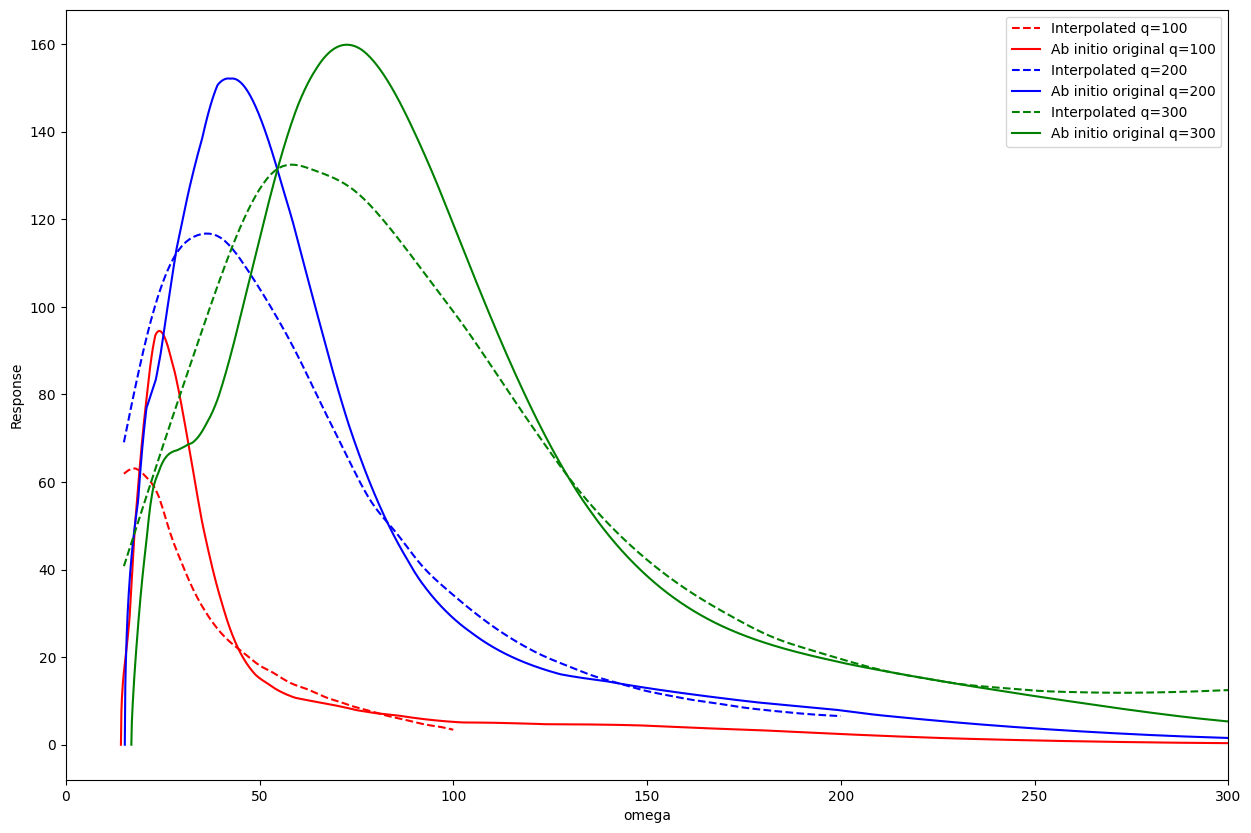

In [68]:
plt.figure(figsize=(15, 10))
colors = ["red", "blue", "green"]
for i, (ab_initio_index, q) in enumerate(zip([1, 3, 5], [100, 200, 300])):
    wvals = np.arange(0, 500, 1)
    residual_pred = model.make_transformed_prediction(q, wvals)
    predicted_final = spectral_functions[0]((q, wvals))*USE_RESIDUALS + residual_pred[:, 0]
    plt.plot(wvals, predicted_final, label=f"Interpolated q={q}", color=colors[i], linestyle="--")
    plt.plot(ab_initio_vals[ab_initio_index,0,0], ab_initio_vals[ab_initio_index,0,1], label=f"Ab initio original q={q}", color=colors[i])

plt.legend()
plt.xlim(0, 300)
plt.xlabel("omega")
plt.ylabel("Response")